**Ανάλυση Δεδομένων**

**Βαρελάς Κωνσταντίνος**

**Εργασία: Credit Risk Dataset**

**Dataset** : https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
print(f"Pandas version: {pd.__version__}")

import matplotlib.pyplot as plt

credit_risk_dataset = pd.read_csv("credit_risk_dataset.csv",sep=",")
print(f"Dataset: {credit_risk_dataset.shape[0]} γραμμές, {credit_risk_dataset.shape[1]} στήλες")

Pandas version: 2.3.3
Dataset: 32581 γραμμές, 12 στήλες


In [3]:
file = "credit_risk_dataset.csv"
credit_risk_dataset = pd.read_csv(file,sep=",")
print(credit_risk_dataset)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

In [4]:
print(credit_risk_dataset.shape)

(32581, 12)


To dataset έχει 32581
**αντικείμενα** και 12 **μεταβλητές**

In [5]:
print(credit_risk_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [6]:
print(credit_risk_dataset["person_home_ownership"].unique())

print(credit_risk_dataset["loan_intent"].unique())

print(credit_risk_dataset["loan_grade"].unique())

print(credit_risk_dataset["cb_person_default_on_file"].unique())



['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']


**Στοιχεία πελάτη**:'person_age'= ηλικία πελάτη , 'person_income'= είσοδημα του πελάτη, 'person_home_ownership'= το καθεστώς ιδιοκτησίας σπιτιού, 'person_emp_length'= χρόνια εργασίας

**Στοιχεία Δανείου**:'loan_intent'= σκοπός αίτησης δανείου, 'loan_amnt'= ποσό δανείου, 'loan_int_rate'= επιτόκιο δανείου, 'loan_status'= κατάσταση δανείου, 'loan_percent_income'= ποσοστό ετησίου εισοδήματος που αντιπροσωπευεί το δάνειο, 'loan_grade'= βαθμός δανείου 

**Άλλα στοιχεία**:'cb_person_default_on_file'= ιστορικό αθέτησης πληρωμών, 'cb_person_cred_hist_length'= διάρκεια πιστωτικού ιστορικού

**Τιμές που παίρνουν οι κατηγορικές μεταβλητές:**

person_home_ownership: 'RENT', 'OWN', 'MORTGAGE', 'OTHER'

loan_intent: 'PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION'

loan_grade: 'D', 'B', 'C', 'A', 'E', 'F', 'G'

cb_person_default_on_file: 'Y', 'N'










In [7]:
print(credit_risk_dataset.isna().sum())
missing_counts = credit_risk_dataset.isna().sum()
print("Στήλες με ελλείπουσες τιμές:\n", missing_counts[missing_counts > 0])

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Στήλες με ελλείπουσες τιμές:
 person_emp_length     895
loan_int_rate        3116
dtype: int64


**Στήλες με ελλείπουσες τιμές**: 

'person_emp_length': 895

'loan_int_rate': 3116

In [8]:
print("μοναδικές τιμές της στήλης:",credit_risk_dataset["loan_status"].unique())

μοναδικές τιμές της στήλης: [1 0]


In [9]:
print(credit_risk_dataset["loan_status"].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


Υποθέτω για τα δεδομένα μου ότι :

**Μεταβλητή στόχος** για το dataset είναι η **"loan_status"**

**Μεταβλητές που επηραζούν τη μεταβλητή στόχος** για το dataset είναι η **"loan_percent_income"**, **"loan_int_rate"**, **"loan_grade"**, **loan_amnt"**, **"cb_person_default_on_file"**, **"cb_person_cred_hist_length"**, **"person_income"**

**Αδιάφορες μεταβλητές** για το dataset είναι **"person_age"**, **"loan_intent"**, **"person_emp_length"**, **"person_home_ownership"**

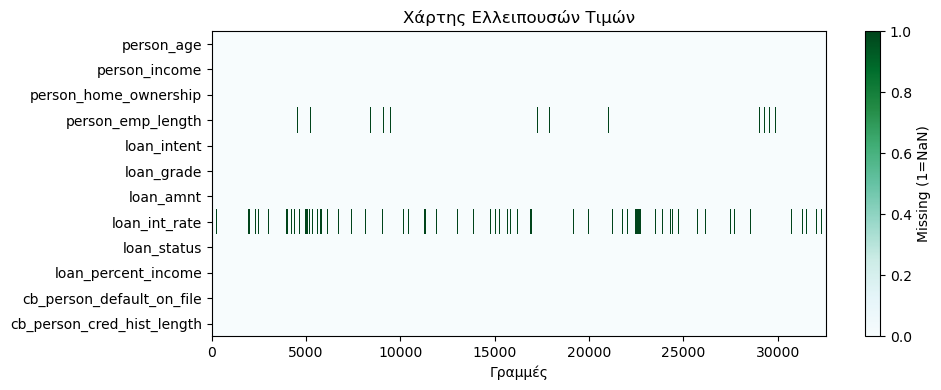

In [10]:
plt.figure(figsize=(10, 4))
plt.imshow(credit_risk_dataset.isna().T, aspect='auto', cmap='BuGn', interpolation='none')
plt.colorbar(label='Missing (1=NaN)')
plt.yticks(range(len(credit_risk_dataset.columns)), credit_risk_dataset.columns)
plt.xlabel('Γραμμές')
plt.title('Χάρτης Ελλειπουσών Τιμών')
plt.tight_layout()
plt.show()

In [11]:
credit_risk_dataset_clean = credit_risk_dataset.copy()

credit_risk_dataset_clean = credit_risk_dataset_clean.dropna(subset=["loan_int_rate"])

print("Πριν:", credit_risk_dataset.shape)
print("Μετά:", credit_risk_dataset_clean.shape)

Πριν: (32581, 12)
Μετά: (29465, 12)


In [12]:
median_person_emp_length = credit_risk_dataset_clean['person_emp_length'].median()
print("Χρόνια εργασίας:", median_person_emp_length)

credit_risk_dataset_clean['person_emp_length'] = credit_risk_dataset_clean['person_emp_length'].fillna(median_person_emp_length)

credit_risk_dataset_clean['person_emp_length'].isna().sum()

Χρόνια εργασίας: 4.0


np.int64(0)

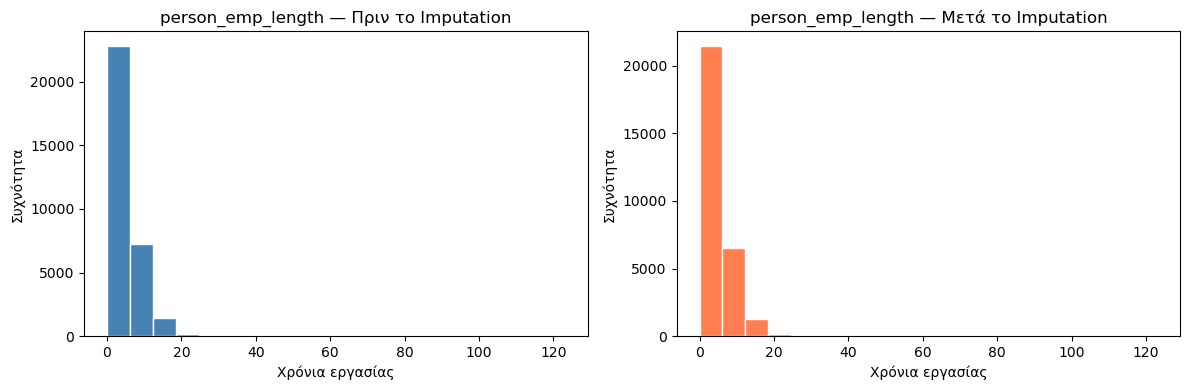

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Πριν: Age στο αρχικό dataset με NaN (αγνοούνται αυτόματα)
axes[0].hist(credit_risk_dataset['person_emp_length'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('person_emp_length — Πριν το Imputation')
axes[0].set_xlabel('Χρόνια εργασίας')
axes[0].set_ylabel('Συχνότητα')


axes[1].hist(credit_risk_dataset_clean['person_emp_length'].dropna(), bins=20, color='coral', edgecolor='white')
axes[1].set_title('person_emp_length — Μετά το Imputation')
axes[1].set_xlabel('Χρόνια εργασίας')
axes[1].set_ylabel('Συχνότητα')


plt.tight_layout()
plt.show()

**Διαχείριση της ordinal μεταβλητής**

[3 1 2 0 4 5 6]


**Διαχείριση των Nominal μεταβλητών**

In [15]:
credit_risk_dataset_onehot = pd.get_dummies(credit_risk_dataset_labels, columns=['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
                                            , drop_first=True)

print(credit_risk_dataset_onehot.columns)
print(credit_risk_dataset_onehot.head(5))

Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='object')
   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
0          22          59000              123.0           3      35000   
1          21           9600                5.0           1       1000   
2          25           9600                1.0           2       5500   
3          23          65500                4.0           2      35000   
4          24          54400                8.0           2      35000   

   loan_int_rate  loan_status  loan_percent_income  \
0          16.02  

In [16]:
credit_risk_dataset_clean[['person_home_ownership', 'loan_intent', 'cb_person_default_on_file', 'loan_grade']].describe()

,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade
count,29465,29465,29465,29465
unique,4,6,2,7
top,RENT,EDUCATION,N,A
freq,14893,5854,24252,9774


In [17]:
credit_risk_dataset_clean.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,29465.000000,2.946500e+04,29465.000000,29465.000000,29465.000000,29465.000000,29465.000000,29465.000000
mean,27.714712,6.602047e+04,4.766537,9584.744612,11.011695,0.219379,0.170110,5.788257
std,6.300193,6.190142e+04,4.097976,6316.272282,3.240459,0.413833,0.106879,4.031987
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.910000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**ΜΟΝΟΜΕΤΑΒΛΗΤΗ ΑΝΑΛΥΣΗ**

**Histogramms:**

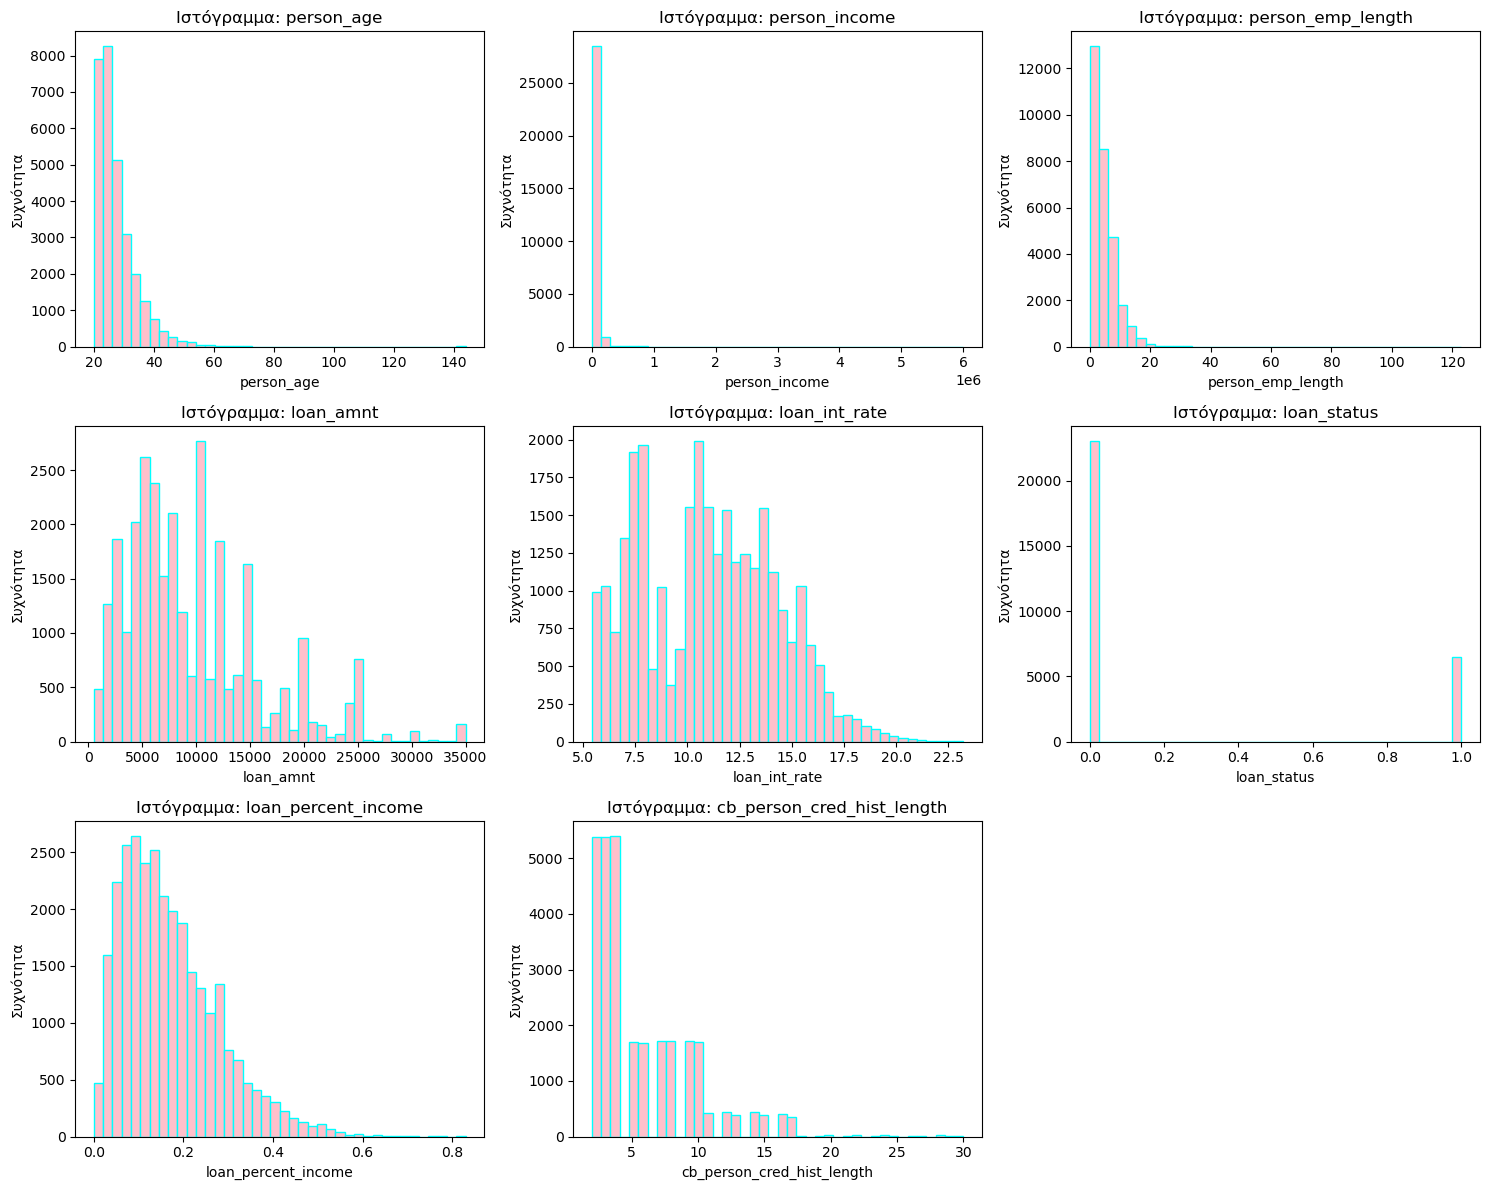

In [18]:
numeric_variables = ["person_age", "person_income", "person_emp_length", "loan_amnt", 
    "loan_int_rate", "loan_status", "loan_percent_income", "cb_person_cred_hist_length"] 
plt.figure(figsize=(15, 12))
i = 1
for numeric in numeric_variables:
    plt.subplot(3, 3, i)
    plt.hist(credit_risk_dataset_clean[numeric], bins=40, color='pink', edgecolor='cyan')
    plt.title(f'Ιστόγραμμα: {numeric}')
    plt.xlabel(numeric)
    plt.ylabel('Συχνότητα')
    i = i + 1
plt.tight_layout()
plt.show()


**Παρατήρηση για ιστόγραμμα της μεταβλητής loan_status**

Παρόλο που η μεταβλητή loan_status αποτελείται από ακεραίους, εμείς την θεωρούμε κατηγορική. Όταν είναι 0 σημαίνει πως ο πελάτης έχει ξοφλήσει το δάνειο, 1 όταν δεν έχουν ξοφλήσει το δάνειο. Οπότε για την σωστή οπτικοποίηση της συχνοτητά της θα φτιάξουμε bar chart.

**Συμπεράσματα Αριθμητικών Μεταβλητών (Histogramms)**

**Bar plots:**

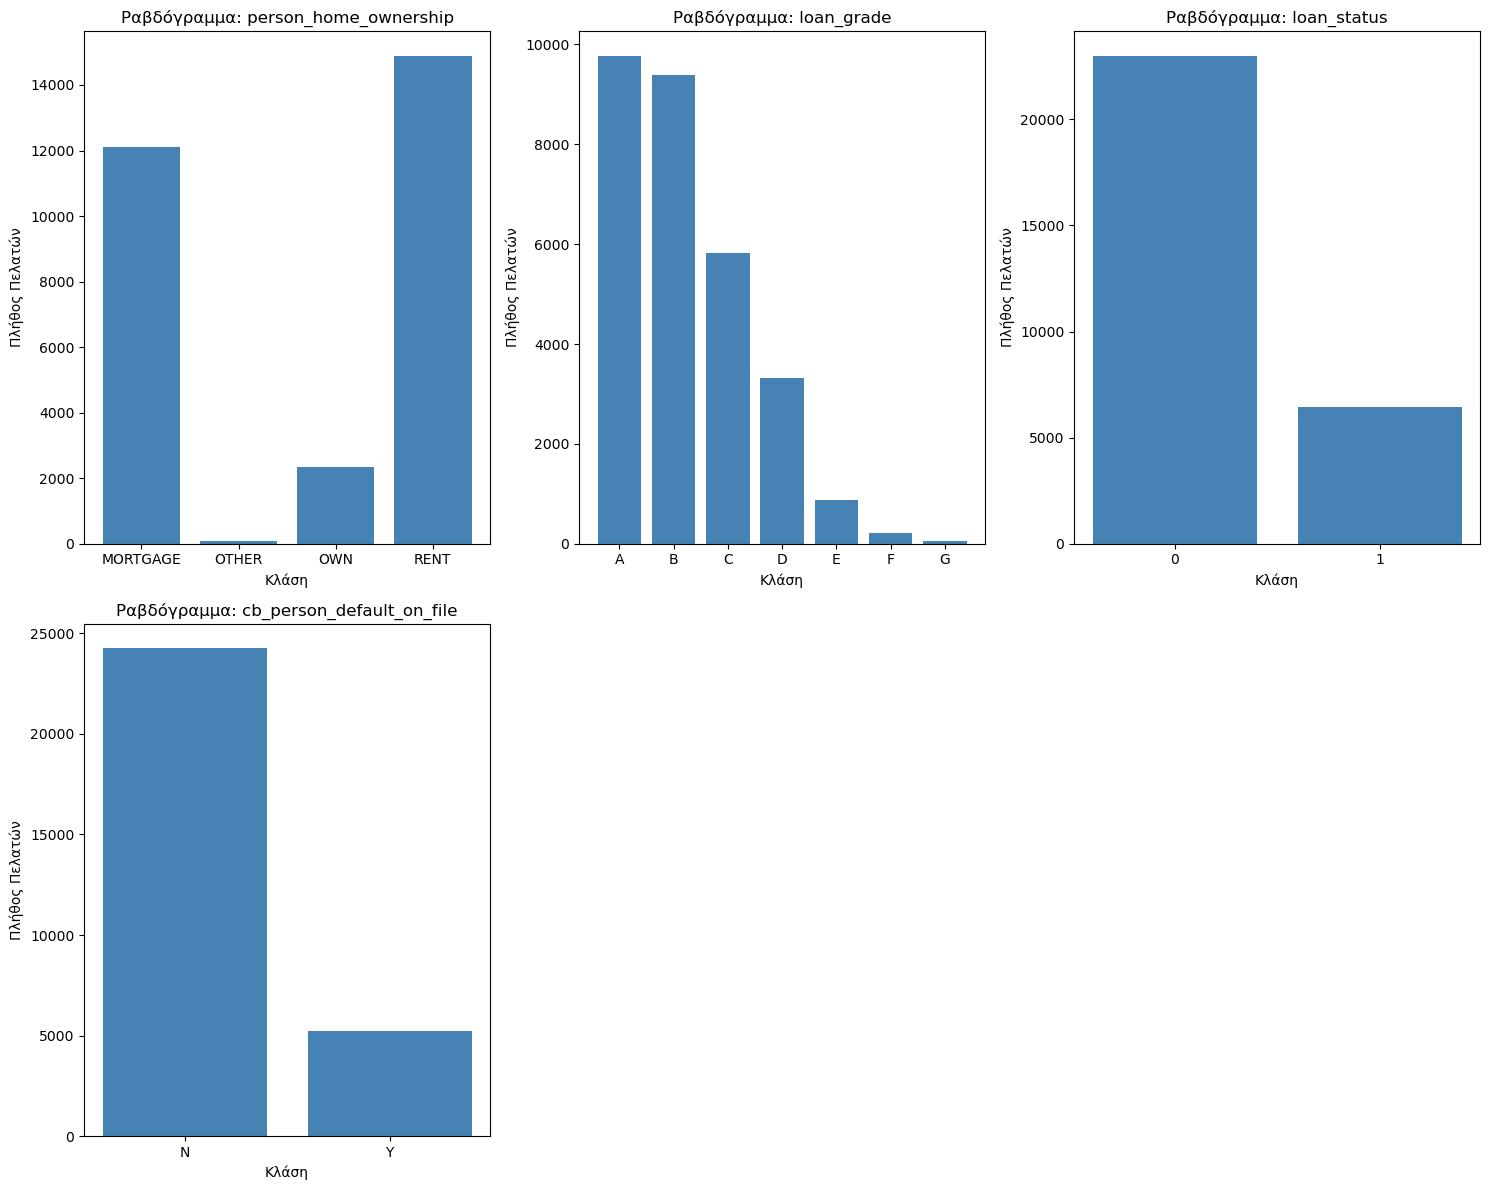

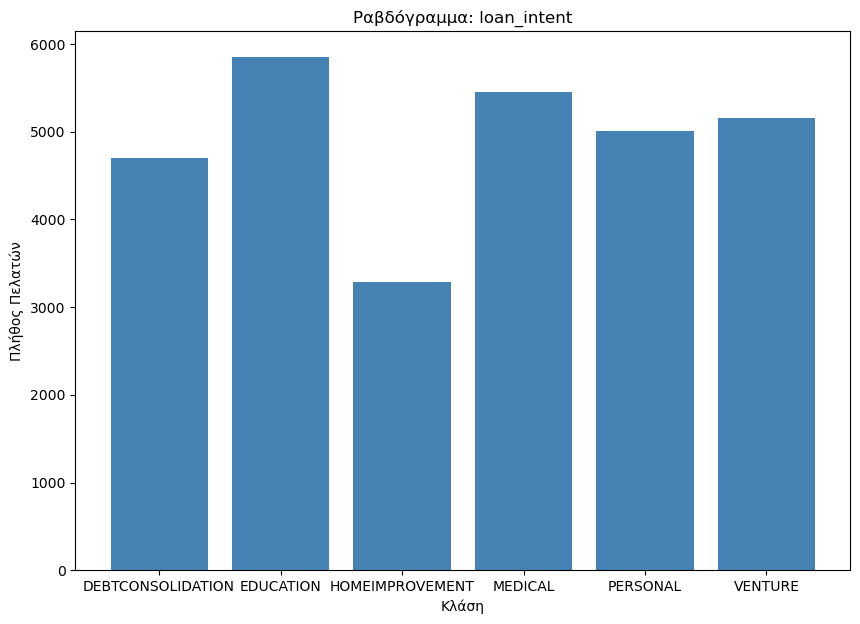

In [19]:
categorical_variables = ["person_home_ownership", "loan_grade", "loan_status", "cb_person_default_on_file"]
plt.figure(figsize=(15, 12))
i = 1
for categorical in categorical_variables:
  plt.subplot(2, 3, i)
  counts = credit_risk_dataset_clean[categorical].value_counts().sort_index()
  plt.bar(counts.index.astype(str), counts.values, color='steelblue')
  plt.title(f'Ραβδόγραμμα: {categorical}')
  plt.xlabel('Κλάση')
  plt.ylabel('Πλήθος Πελατών')
  
  i = i + 1
plt.tight_layout()
plt.show()

counts = credit_risk_dataset_clean['loan_intent'].value_counts().sort_index()

plt.figure(figsize=(10, 7))
plt.bar(counts.index.astype(str), counts.values, color='steelblue')
plt.title('Ραβδόγραμμα: loan_intent')
plt.xlabel('Κλάση')
plt.ylabel('Πλήθος Πελατών')
plt.show()



**Συμπεράσματα Κατηγορικών Μεταβλητών (Bar plots)**

**Ιδιοκτησία Κατοικίας (person_home_ownership)**: Οι περισσότεροι δανειολήπτες νοικιάζουν το σπίτι τους ή το έχουν σε υποθήκη. Η λιγότεροι έχουν σπίτι στην ιδιοκτησία τους.

**Βαθμίδα Δανείου (loan_grade)**: Τα περισσότερα δάνεια είναι χαμηλού ρίσκου, κατηγορίας Α και Β. Όσο προχωράμε σε κατηγορίες υψηλότερου ρίσκου (D, E, F, G), ο αριθμός των δανείων μειώνεται δραματικά.

**Κατάσταση Δανείου (loan_status)**: Το μεγαλύτερο ποσοστό των πελατών πληρώνουν το δάνειο τους, ενώ ένα μικρότερο ποσοστό αθετεί την πληρωμή του δανείου.

**Ιστορικό Αθέτησης (cb_person_default_on_file)**:Το μεγαλύτερο ποσοστό των πελατών δεν έχει προηγούμενο ιστορικό αθέτησης δανείου.

**Σκοπός Δανείου (loan_intent)**: Η πλειοψηφία των πελατών ζητά δάνεια κυρίως για Εκπαίδευση και Ιατρικά έξοδα. Η μειοψηφία των πελατών παίρνουν δάνειο για ανακαίνιση σπιτιού.



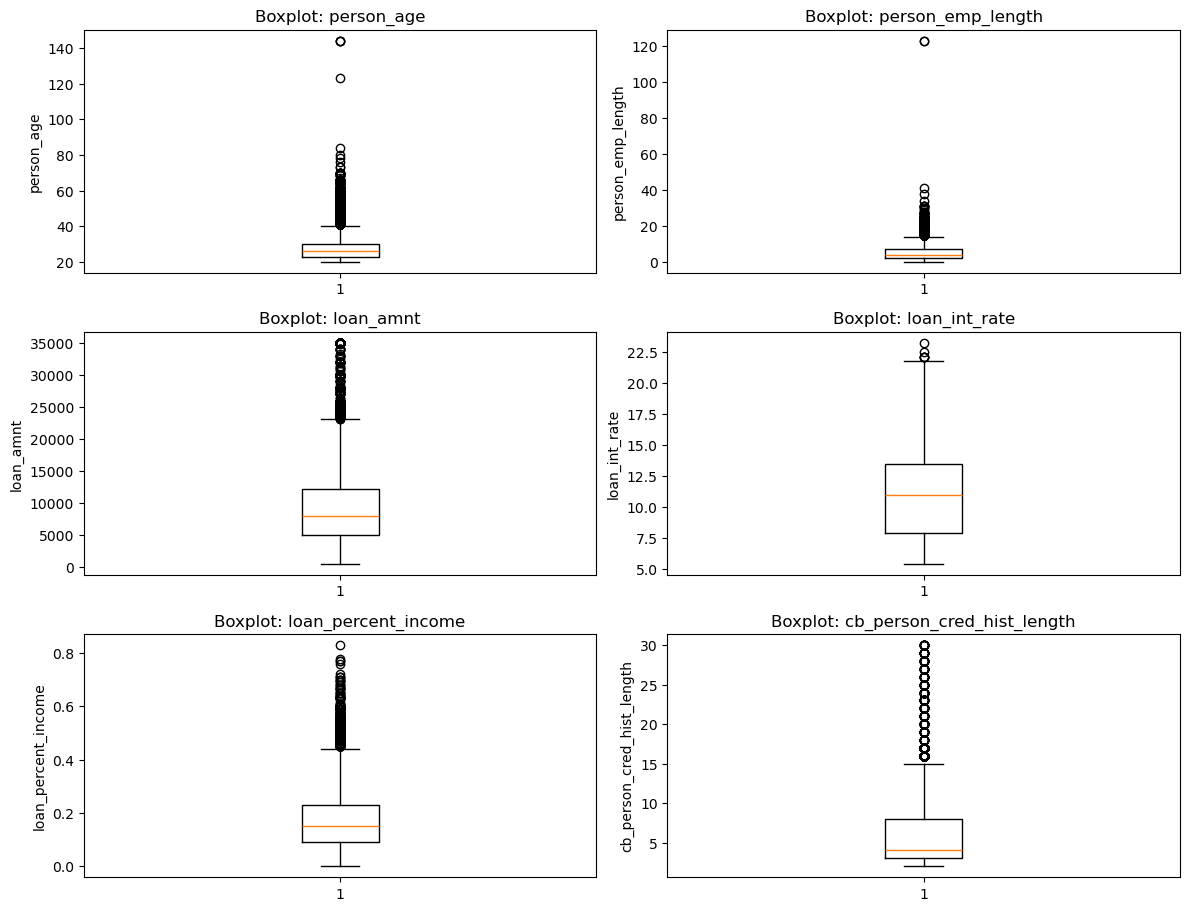

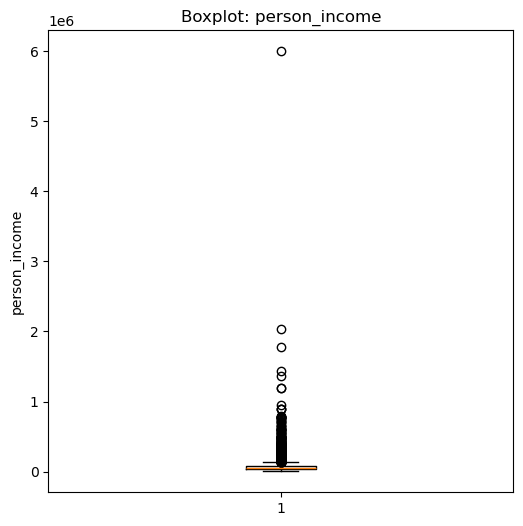

In [20]:
boxplot_variables = ["person_age", "person_emp_length", "loan_amnt", 
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"] 
plt.figure(figsize=(12, 12))
i = 1
for col in boxplot_variables:
    plt.subplot(4, 2, i)
    plt.boxplot(credit_risk_dataset_clean[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    i = i + 1
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(credit_risk_dataset_clean["person_income"].dropna())
plt.title('Boxplot: person_income')
plt.ylabel("person_income")
plt.show()



**Αντιμετώπιση Ακραίων Τιμών**

**person_age boxplot:** Μέσω του boxplot person_age εντόπισα τιμές που συνιστούν προφανή λάθη καταχώρησης (π.χ ηλικία 140 χρονών). Οπότε κράτησα τις τιμές όπου η ηλικίες είναι χαμηλότερες ή ίσες με 100 χρονών.

**person_emp_length boxplot:** Αντίστοιχα και στα χρόνια εργασίας (person_emp_length) παρατήρησα ότι εμφανίζεται μια τιμή πελάτη 120 χρόνια , τιμή η οποία είναι ανδύνατη.

**person_income boxplot:** Έχουμε μια ακραία τίμη στα 6 εκατομμύρια όπου τραβάει τον μέσο όρο προς τα πάνω ξεγελώντας τους άλλους αριθμούς, οπότε πρέπει να του κάνουμε capping.

**Συμπεράσματα Αριθμητικών Μεταβλητών (Boxplots):**

**loan_int_rate:** Το επιτόκιο έχει τα λιγότερα outliers το οποίο είναι φυσιολογικό καθώς σε αντίθεση με μεταβλητές όπως το εισόδημα που δηλώνονται από τον πελάτη που μπορεί να κυμαίνεται σε ένα μεγάλο εύρος αριθμών, το επιτόκιο έχει συγκεκρίμενες τιμές σύμφωνα με τους όρους που πρέπει να υπακούν οι τράπεζες, αποτρέποντας την ύπαρξη παράλογων ακραίων τιμών.

**loan_amnt, cb_person_cred_hist_length και loan_percent_income:** Σε αυτές τις μεταβλητές βλέπουμε φυσιολογικές ακραίες τιμές που αντιπροσωπεύουν την μειοψηγία των πελατών.

In [21]:
credit_risk_dataset_clean = credit_risk_dataset_clean[credit_risk_dataset_clean['person_age'] <= 100]
credit_risk_dataset_clean = credit_risk_dataset_clean[credit_risk_dataset_clean["person_emp_length"] <=80]


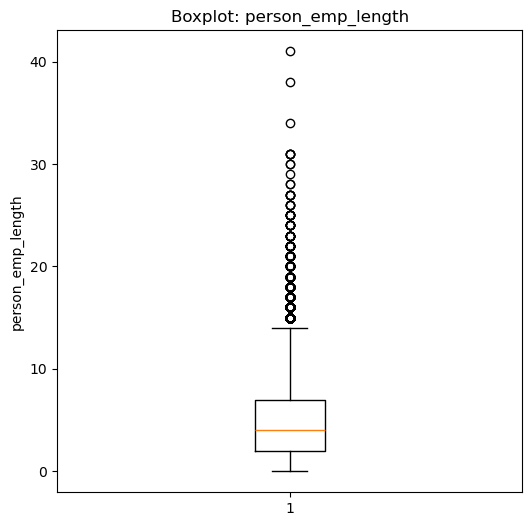

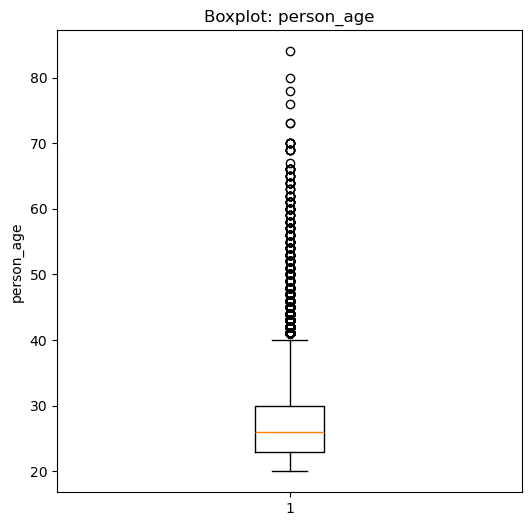

In [22]:
plt.figure(figsize=(6, 6))
plt.boxplot(credit_risk_dataset_clean["person_emp_length"].dropna())
plt.title('Boxplot: person_emp_length')
plt.ylabel("person_emp_length")
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(credit_risk_dataset_clean["person_age"].dropna())
plt.title('Boxplot: person_age')
plt.ylabel("person_age")
plt.show()

Mέγιστη τιμή: 900000


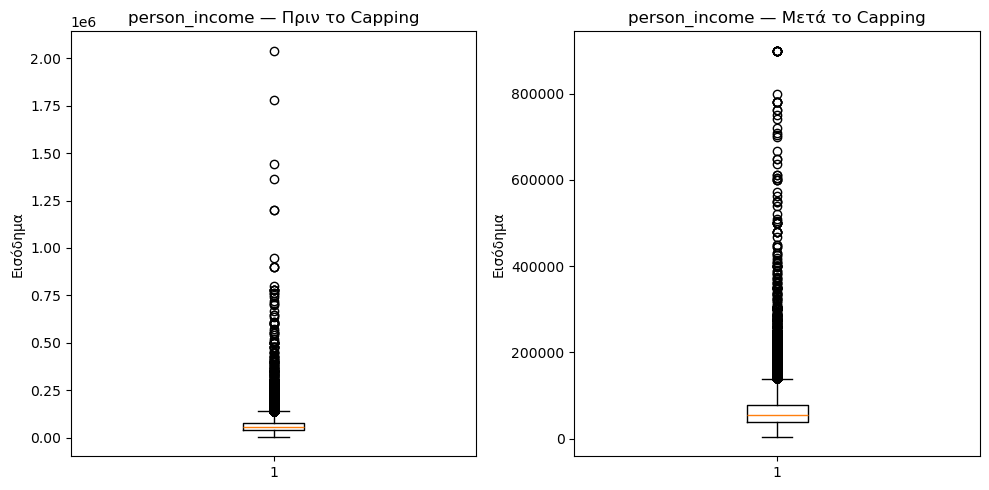

In [23]:
lower_limit = 0
upper_limit = 900000
credit_risk_dataset_clean['person_income_capped'] = credit_risk_dataset_clean['person_income'].clip(lower=lower_limit, upper=upper_limit)

print("Mέγιστη τιμή:", credit_risk_dataset_clean['person_income_capped'].max())


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(credit_risk_dataset_clean['person_income'])
axes[0].set_title('person_income — Πριν το Capping')
axes[0].set_ylabel('Εισόδημα')

axes[1].boxplot(credit_risk_dataset_clean['person_income_capped'])
axes[1].set_title('person_income — Μετά το Capping')
axes[1].set_ylabel('Εισόδημα')

plt.tight_layout()
plt.show()

In [24]:
print(credit_risk_dataset_clean["person_age"].skew().round(3), credit_risk_dataset_clean["person_age"].kurtosis().round(3))
print(credit_risk_dataset_clean["person_income"].skew().round(3), credit_risk_dataset_clean["person_income"].kurtosis().round(3))
print(credit_risk_dataset_clean["person_emp_length"].skew().round(3), credit_risk_dataset_clean["person_emp_length"].kurtosis().round(3))
print(credit_risk_dataset_clean["loan_amnt"].skew().round(3), credit_risk_dataset_clean["loan_amnt"].kurtosis().round(3))
print(credit_risk_dataset_clean["loan_int_rate"].skew().round(3), credit_risk_dataset_clean["loan_int_rate"].kurtosis().round(3))
print(credit_risk_dataset_clean["loan_percent_income"].skew().round(3), credit_risk_dataset_clean["loan_percent_income"].kurtosis().round(3))
print(credit_risk_dataset_clean["cb_person_cred_hist_length"].skew().round(3), credit_risk_dataset_clean["cb_person_cred_hist_length"].kurtosis().round(3))

1.918 5.565
8.996 201.345
1.287 2.641
1.184 1.384
0.209 -0.672
1.071 1.256
1.656 3.687


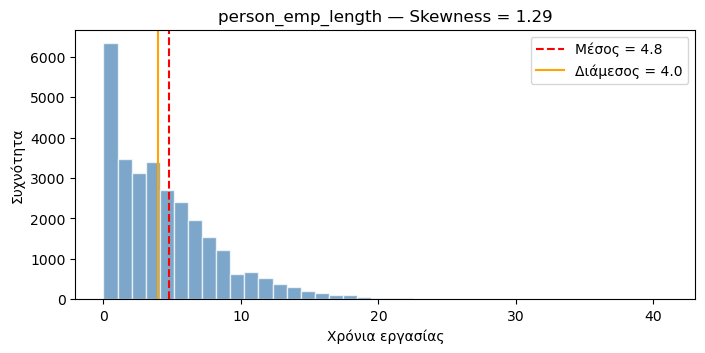

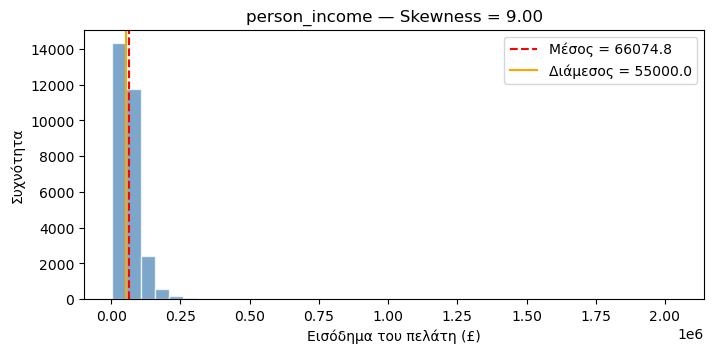

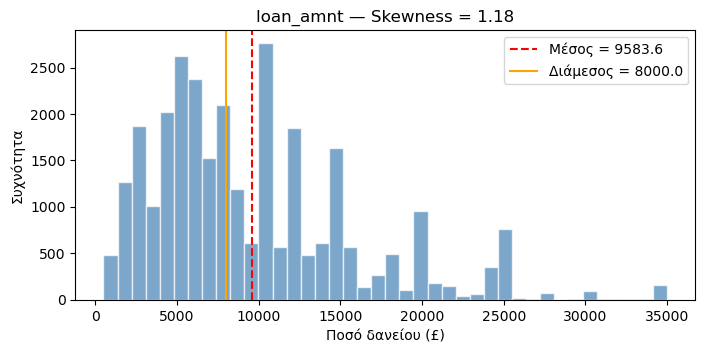

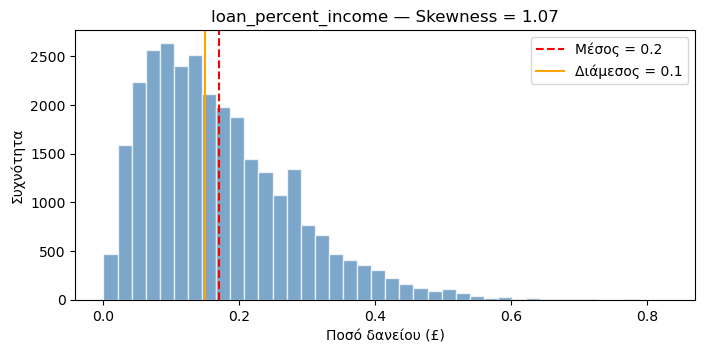

In [25]:
plt.figure(figsize=(8, 3.5))
plt.hist(credit_risk_dataset_clean["person_emp_length"], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(credit_risk_dataset_clean["person_emp_length"].mean(), color='red', linestyle='--',
            label=f'Μέσος = {credit_risk_dataset["person_emp_length"].mean():.1f}')
plt.axvline(credit_risk_dataset_clean["person_emp_length"].median(), color='orange', linestyle='-',
            label=f'Διάμεσος = {credit_risk_dataset_clean["person_emp_length"].median():.1f}')
plt.legend()
plt.title(f'person_emp_length — Skewness = {credit_risk_dataset_clean["person_emp_length"].skew():.2f}')
plt.xlabel('Χρόνια εργασίας')
plt.ylabel('Συχνότητα')
plt.show()

plt.figure(figsize=(8, 3.5))
plt.hist(credit_risk_dataset_clean["person_income"], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(credit_risk_dataset_clean["person_income"].mean(), color='red', linestyle='--',
            label=f'Μέσος = {credit_risk_dataset["person_income"].mean():.1f}')
plt.axvline(credit_risk_dataset_clean["person_income"].median(), color='orange', linestyle='-',
            label=f'Διάμεσος = {credit_risk_dataset_clean["person_income"].median():.1f}')
plt.legend()
plt.title(f'person_income — Skewness = {credit_risk_dataset_clean["person_income"].skew():.2f}')
plt.xlabel('Εισόδημα του πελάτη (£)')
plt.ylabel('Συχνότητα')
plt.show()

plt.figure(figsize=(8, 3.5))
plt.hist(credit_risk_dataset_clean["loan_amnt"], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(credit_risk_dataset_clean["loan_amnt"].mean(), color='red', linestyle='--',
            label=f'Μέσος = {credit_risk_dataset_clean["loan_amnt"].mean():.1f}')
plt.axvline(credit_risk_dataset_clean["loan_amnt"].median(), color='orange', linestyle='-',
            label=f'Διάμεσος = {credit_risk_dataset_clean["loan_amnt"].median():.1f}')
plt.legend()
plt.title(f'loan_amnt — Skewness = {credit_risk_dataset_clean["loan_amnt"].skew():.2f}')
plt.xlabel('Ποσό δανείου (£)')
plt.ylabel('Συχνότητα')
plt.show()

plt.figure(figsize=(8, 3.5))
plt.hist(credit_risk_dataset_clean["loan_percent_income"], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(credit_risk_dataset_clean["loan_percent_income"].mean(), color='red', linestyle='--',
            label=f'Μέσος = {credit_risk_dataset_clean["loan_percent_income"].mean():.1f}')
plt.axvline(credit_risk_dataset_clean["loan_percent_income"].median(), color='orange', linestyle='-',
            label=f'Διάμεσος = {credit_risk_dataset_clean["loan_percent_income"].median():.1f}')
plt.legend()
plt.title(f'loan_percent_income — Skewness = {credit_risk_dataset_clean["loan_percent_income"].skew():.2f}')
plt.xlabel('Ποσό δανείου (£)')
plt.ylabel('Συχνότητα')
plt.show()

**Σχολιασμός Ασυμμετρίας (Skewness) και Κύρτωσης (Kurtosis)**

Εισόδημα Πελάτη (person_income):
Η κατανομή εμφανίζει έντονη θετική ασυμμετρία (Skewness = 9.00 > 0) με την ουρά να εκτείνεται δεξιά (Mean > Median), ενώ είναι λεπτόκυρτη (Kurtosis > 0), γεγονός που επιβεβαιώνει την ύπαρξη πολλών ακραίων τιμών (outliers) στις υψηλές κλίμακες εισοδήματος.

Ποσό Δανείου (loan_amnt):
H κατανομή εμφανίζει θετική ασυμμετρία (Skewness = 1.18 > 0) με την ουρά να εκτείνεται δεξιά (Mean > Median), υποδεικνύοντας συγκέντρωση των δανείων σε μικρότερα ποσά, ενώ η κατανομή είναι λεπτόκυρτη (μυτερή) με βαρύτερες ουρές από την κανονική.

Χρόνια Εργασίας (person_emp_length):
Η μεταβλητή παρουσιάζει θετική ασυμμετρία (Skewness = 1.29 > 0) με την ουρά της κατανομής να εκτείνεται προς τα δεξιά (Mean > Median). Η κατανομή χαρακτηρίζεται ως λεπτόκυρτη (Kurtosis > 0), καθώς παρατηρείται μεγάλη συγκέντρωση πελατών με λίγα έτη προϋπηρεσίας (0-5 έτη), ενώ οι πελάτες με πολυετή εργασία αποτελούν τις ακραίες τιμές της ουράς.

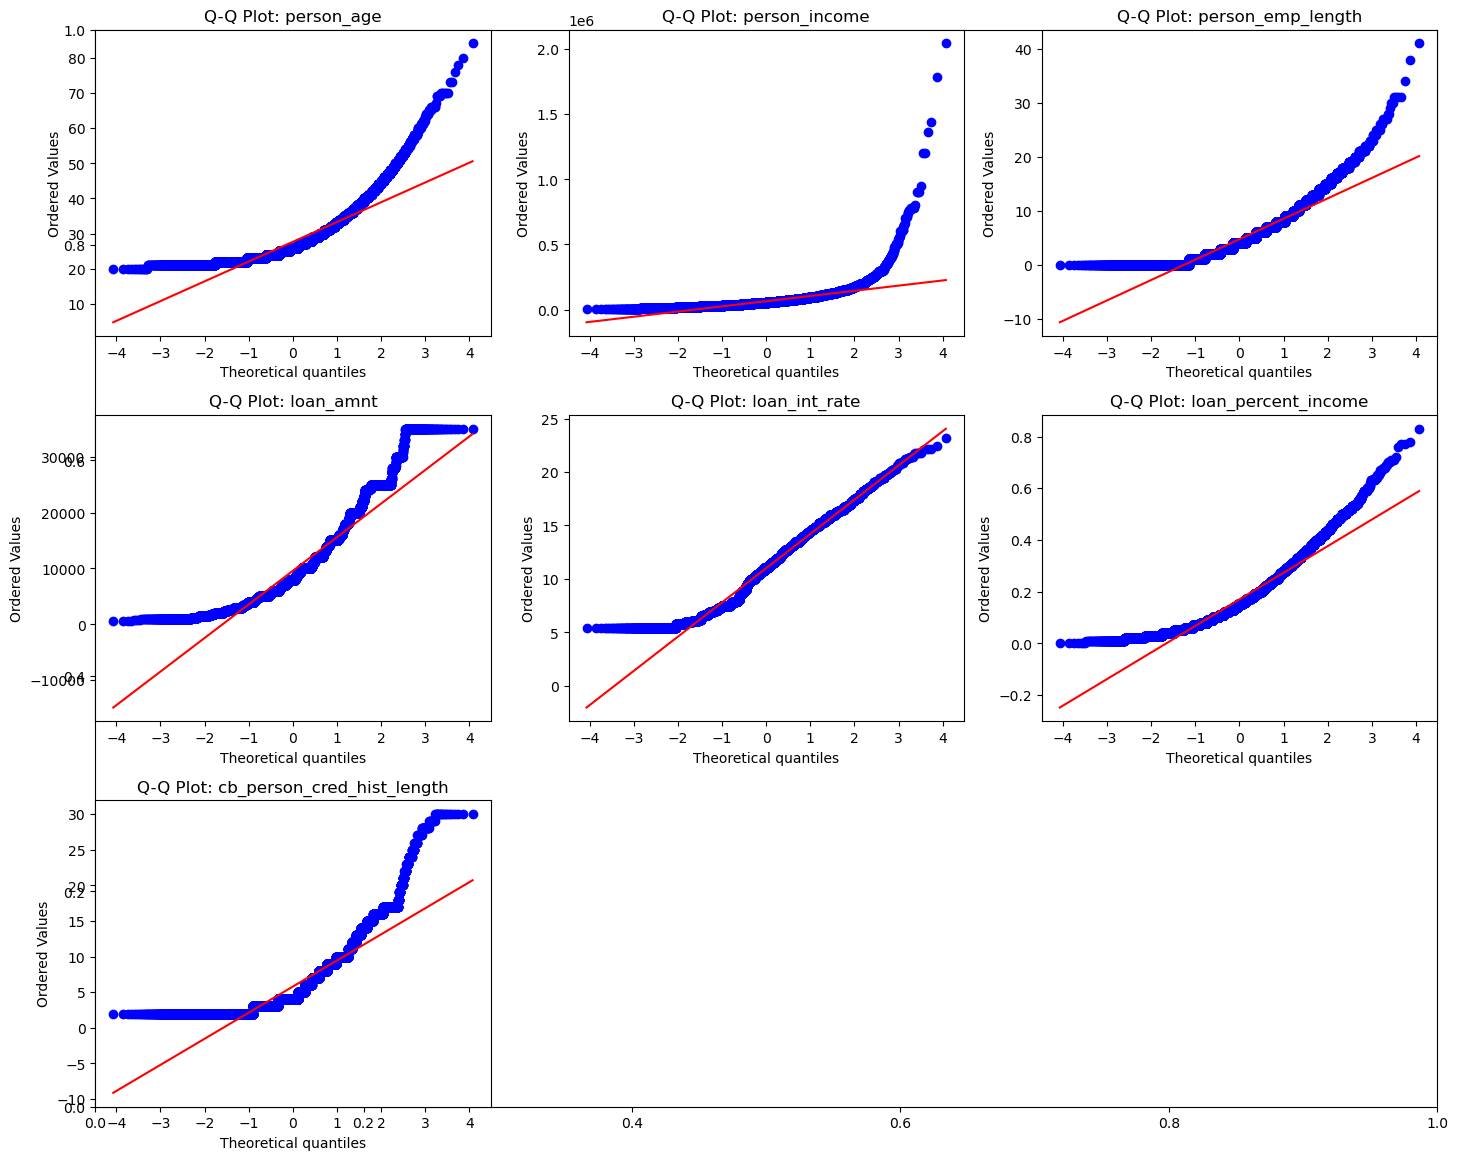

In [26]:
from scipy import stats
numeric_variables = ["person_age", "person_income", "person_emp_length", "loan_amnt", 
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"] 

fig, axes = plt.subplots(figsize=(15, 12))
i = 1
for numeric in numeric_variables:
    plt.subplot(3, 3, i)
    stats.probplot(credit_risk_dataset_clean[numeric], dist='norm', plot=plt)
    plt.title(f'Q-Q Plot: {numeric}')
    i = i + 1

plt.tight_layout()
plt.show()



**Συμπεράσματα Q-Q plot**

**Σύμφωνα με την διαγώνιο:** Η μόνη μεταβλητή που φαίνεται να μοιάζει πιο κοντά στην κανονική κατανομή είναι το loan_int_rate (Επιτόκιο)

**Απόκλιση στις ουρές:** person_income, person_age, person_emp_length, cb_person_cred_hist_length, loan_percent_income, loan_amnt είναι στην κατηγορία (leptokurtic) παρουσιάζουν θετική ασυμμετρία, είναι πιο μυτερές και έχουν βαρύτερες ουρές.

loan_int_rate μοιάζει με τέλεια κανονική κατανομή αλλά δεν είναι απόλυτα Mesokurtic

**Καμπύλη:** Όλες οι μεταβλητές έχουν θετική ασυμμετρία 




**ΠΟΛΥΜΕΤΑΒΛΗΤΗ ΑΝΑΛΥΣΗ**

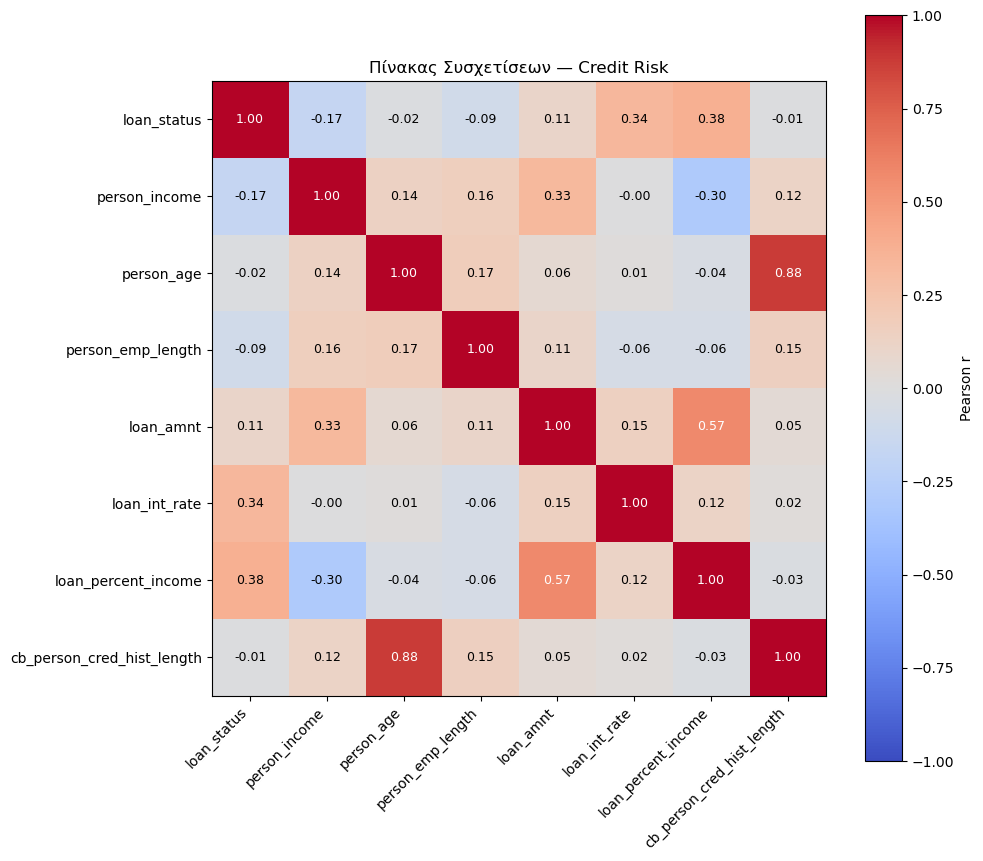

In [27]:
cols = ['loan_status', 'person_income', 'person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
corr_matrix = credit_risk_dataset_clean[cols].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Ετικέτες αξόνων
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

# Τιμές μέσα στα κελιά
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, label='Pearson r')
plt.title('Πίνακας Συσχετίσεων — Credit Risk')
plt.tight_layout()
plt.show()

**Συμπεράσμτα από πίνακα συσχετίσεων:**

Το **loan_percent_income** (0.38) και το **loan_int_rate** (0.34) παρουσιάζουν την υψηλότερη θετική συσχέτιση με την αθέτηση δανείου **(loan_status)**. 

Το **person_income** (-0.17) έχει την πιο έντονη αρνητική συσχέτιση. Όσο αυξάνεται το εισόδημα του δανειολήπτη, τόσο μειώνεται ο κίνδυνος αθέτησης **(loan_status)**. 

Το **loan_amnt** συσχετίζεται θετικά με το **loan_percent_income** (0.57) και με το **person_income** (0.33). Αυτό υποδηλώνει ότι οι πελάτες με υψηλότερα εισοδήματα ζητούν μεγαλύτερα ποσά δανείων, τα οποία με τη σειρά τους καταλαμβάνουν μεγαλύτερο ποσοστό του εισοδήματός τους.

Παρατηρείται αρνητική συσχέτιση μεταξύ **person_income** και **loan_percent_income** (-0.30), δείχνοντας ότι γενικά οι πιο εύποροι πελάτες διατηρούν το δάνειό τους σε χαμηλότερο ποσοστό επί του συνολικού τους εισοδήματος.

Παρατηρείται μια υψηλή συσχέτιση (0.88) μεταξύ της ηλικίας **(person_age)** και της διάρκειας πιστωτικού ιστορικού **(cb_person_cred_hist_length)**.

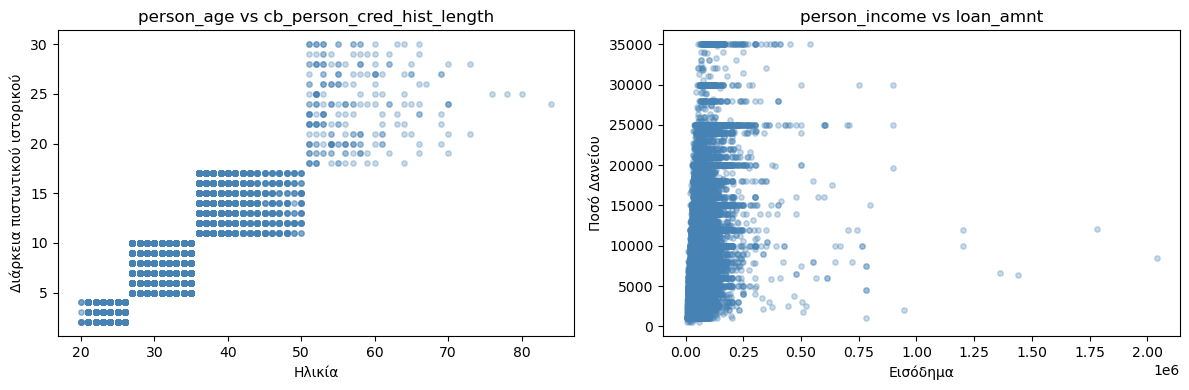

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(credit_risk_dataset_clean['person_age'], credit_risk_dataset_clean['cb_person_cred_hist_length'], alpha=0.3, s=15, color='steelblue')
axes[0].set_xlabel('Ηλικία')
axes[0].set_ylabel('Διάρκεια πιστωτικού ιστορικού')
axes[0].set_title('person_age vs cb_person_cred_hist_length')




axes[1].scatter(credit_risk_dataset_clean['person_income'], credit_risk_dataset_clean['loan_amnt'], alpha=0.3, s=15, color='steelblue')
axes[1].set_xlabel('Εισόδημα')
axes[1].set_ylabel('Ποσό Δανείου')
axes[1].set_title('person_income vs loan_amnt')

plt.tight_layout()
plt.show()

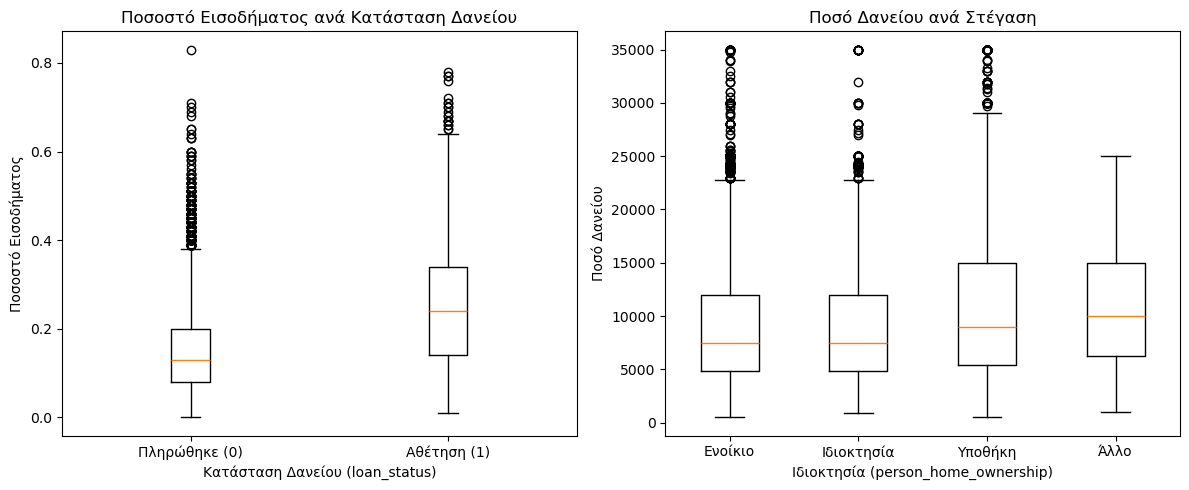

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

boxplot1 = [credit_risk_dataset_clean[credit_risk_dataset_clean['loan_status']==c]['loan_percent_income'].dropna() for c in [0, 1]]

axes[0].boxplot(boxplot1, tick_labels=['Πληρώθηκε (0)', 'Αθέτηση (1)'])
axes[0].set_title('Ποσοστό Εισοδήματος ανά Κατάσταση Δανείου')
axes[0].set_xlabel('Κατάσταση Δανείου (loan_status)')
axes[0].set_ylabel('Ποσοστό Εισοδήματος')

categories = ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
boxplot2 = [credit_risk_dataset_clean[credit_risk_dataset_clean['person_home_ownership']==s]['loan_amnt'].dropna() for s in categories]

axes[1].boxplot(boxplot2, tick_labels=['Ενοίκιο', 'Ιδιοκτησία', 'Υποθήκη', 'Άλλο'])
axes[1].set_title('Ποσό Δανείου ανά Στέγαση')
axes[1].set_xlabel('Ιδιοκτησία (person_home_ownership)')
axes[1].set_ylabel('Ποσό Δανείου')

plt.tight_layout()
plt.show()

In [31]:
credit_risk_dataset_full = pd.get_dummies(credit_risk_dataset_clean, columns=["person_home_ownership","loan_intent",  "loan_grade", "loan_status", "cb_person_default_on_file"])
print(credit_risk_dataset_full.columns)
print(credit_risk_dataset_full.columns.tolist())

print(credit_risk_dataset_full.head())

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'person_income_capped', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'loan_status_0',
       'loan_status_1', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y'],
      dtype='object')
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_income_capped', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OW

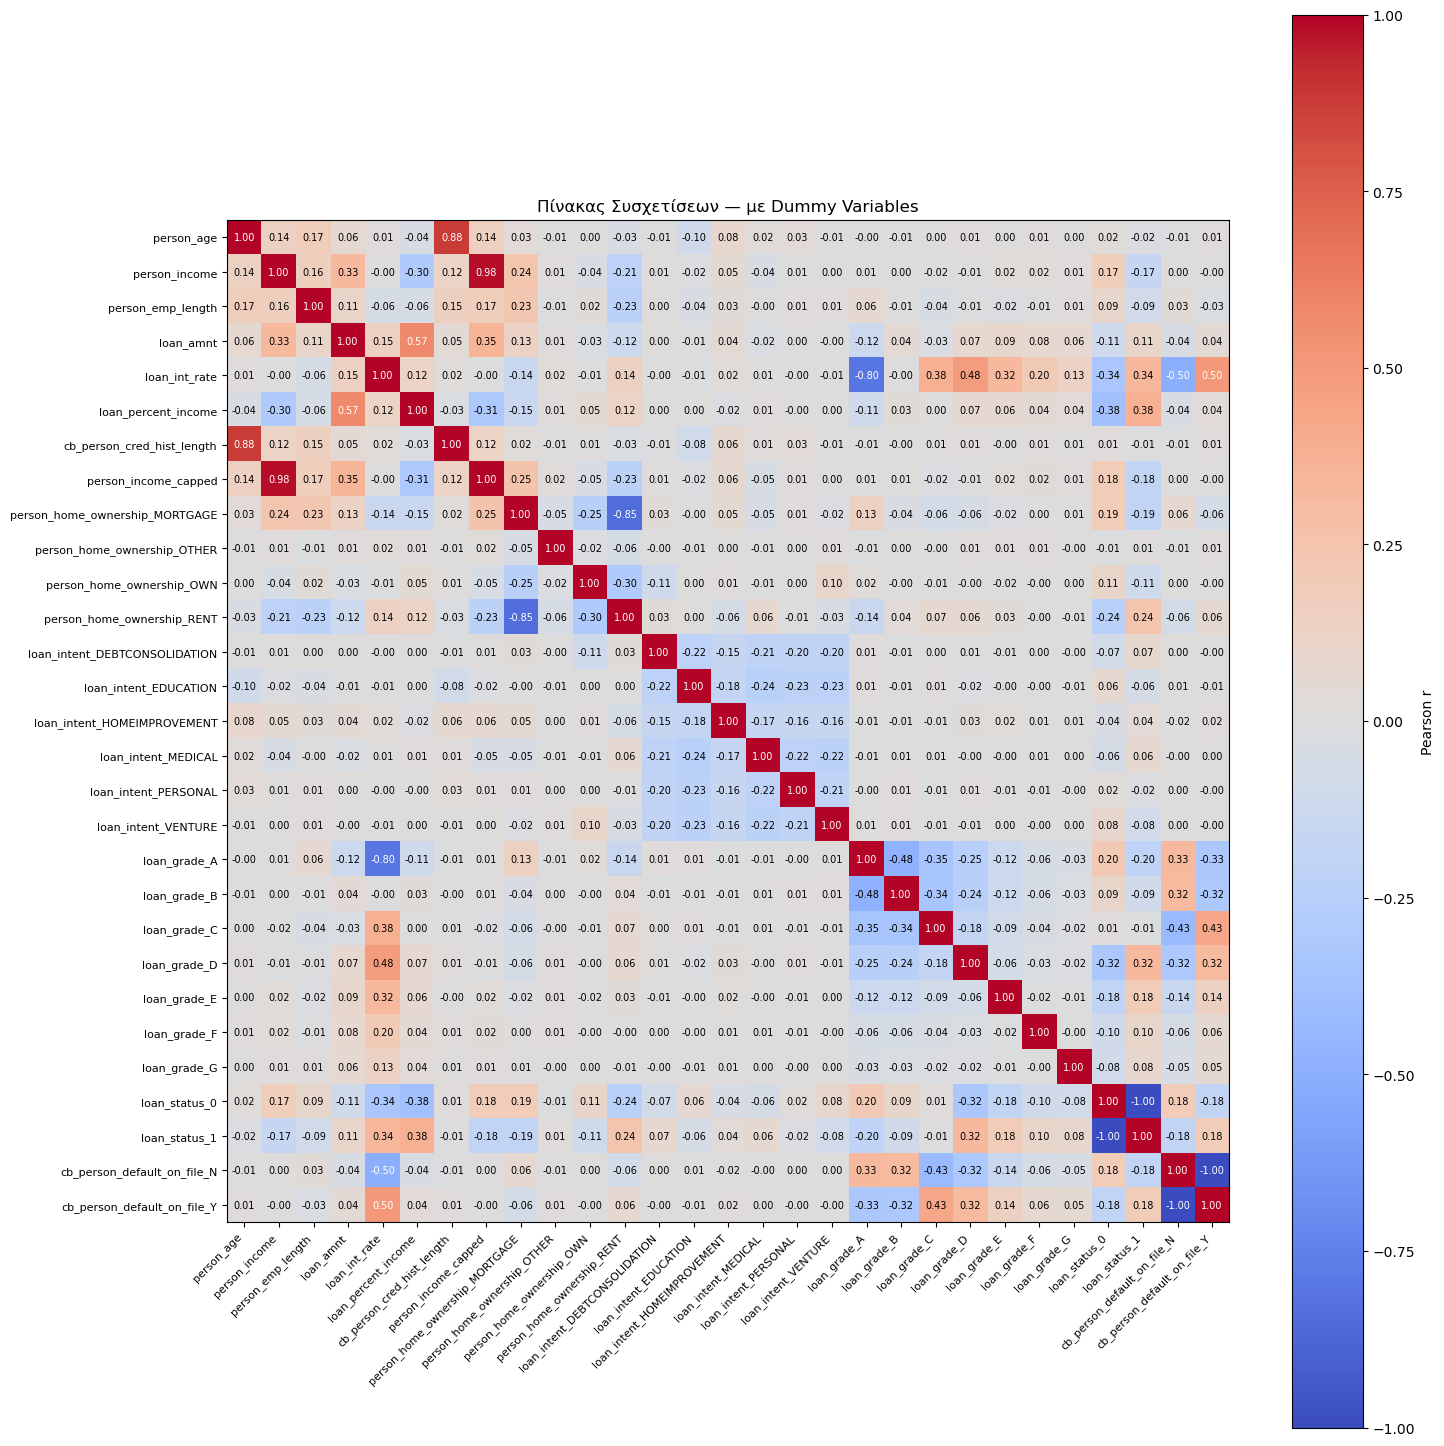

In [32]:
heatmap_cols = ['person_age', 'person_income', 'person_emp_length',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
       'cb_person_cred_hist_length', 'person_income_capped',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'loan_status_0',
       'loan_status_1', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y']
corr_matrix = credit_risk_dataset_full[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(15, 15))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(heatmap_cols, fontsize=8)

for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(val) > 0.5 else 'black')

plt.colorbar(im, label='Pearson r')
plt.title('Πίνακας Συσχετίσεων — με Dummy Variables')
plt.tight_layout()
plt.show()

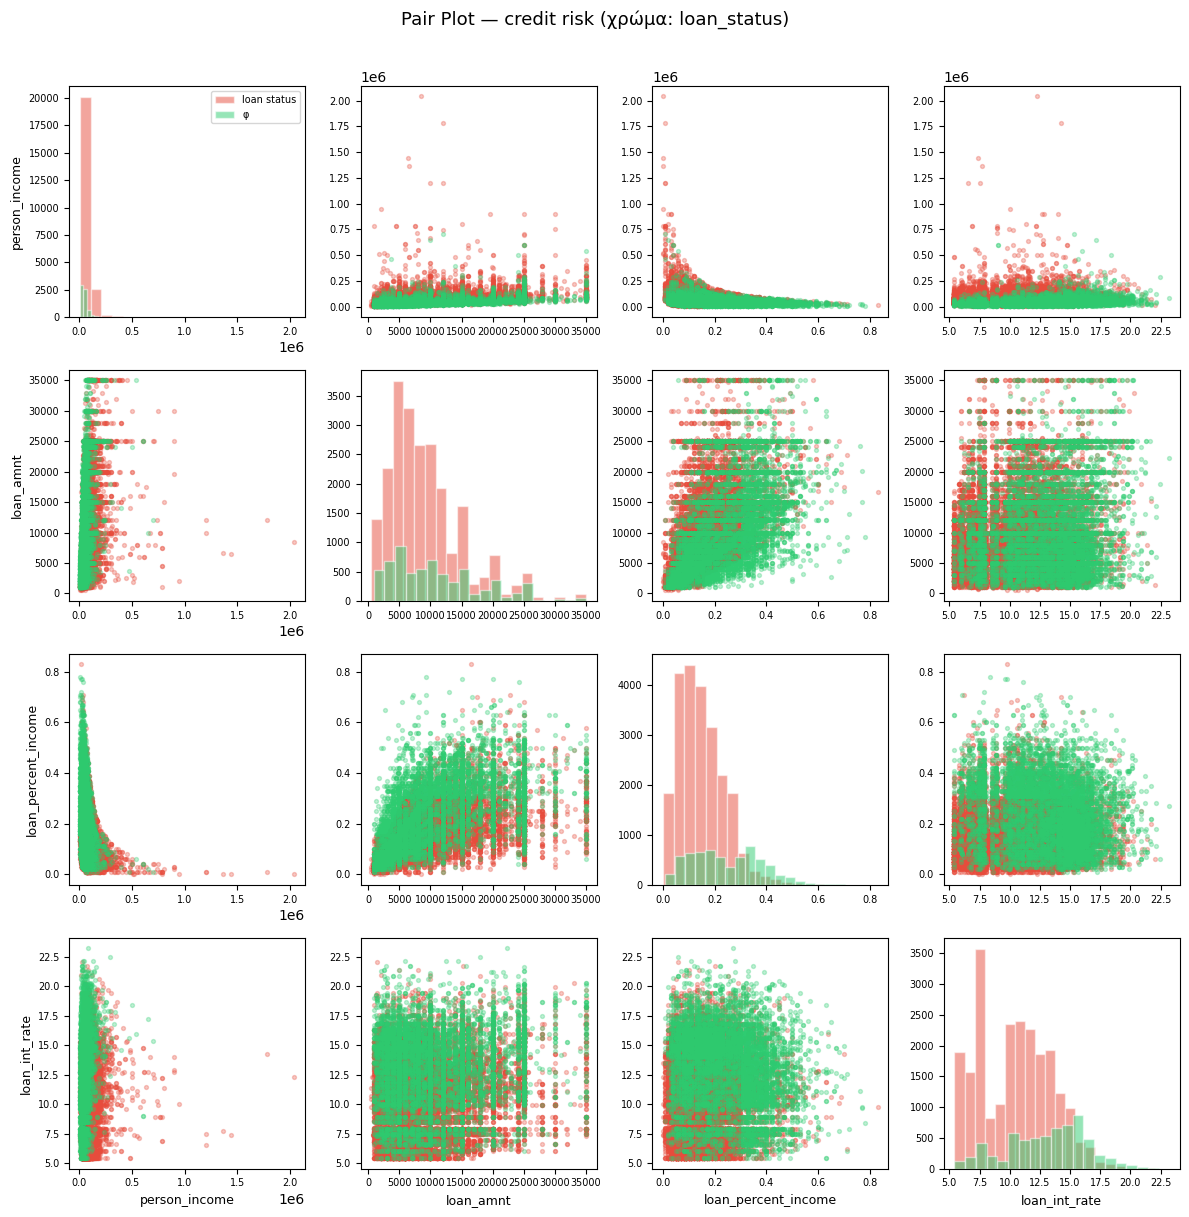

In [44]:
pair_cols = ['person_income', 'loan_amnt', 'loan_percent_income', 'loan_int_rate']
hue_col = 'loan_status'
colors = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'loan status', 1: 'φ'}
n = len(pair_cols)

fig, axes = plt.subplots(n, n, figsize=(12, 12))
for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            for val, color in colors.items():
                ax.hist(credit_risk_dataset_clean[credit_risk_dataset_clean[hue_col]==val][pair_cols[i]],
                        bins=20, alpha=0.5, color=color, edgecolor='white', label=labels[val])
            if i == 0: ax.legend(fontsize=7)
        else:
            for val, color in colors.items():
                mask = credit_risk_dataset_clean[hue_col] == val
                ax.scatter(credit_risk_dataset_clean.loc[mask, pair_cols[j]], credit_risk_dataset_clean.loc[mask, pair_cols[i]],
                          alpha=0.3, s=8, color=color)
        if j == 0: ax.set_ylabel(pair_cols[i], fontsize=9)
        if i == n-1: ax.set_xlabel(pair_cols[j], fontsize=9)
        ax.tick_params(labelsize=7)

plt.suptitle('Pair Plot — credit risk (χρώμα: loan_status)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Pearson r (Fare, Survived): +0.335



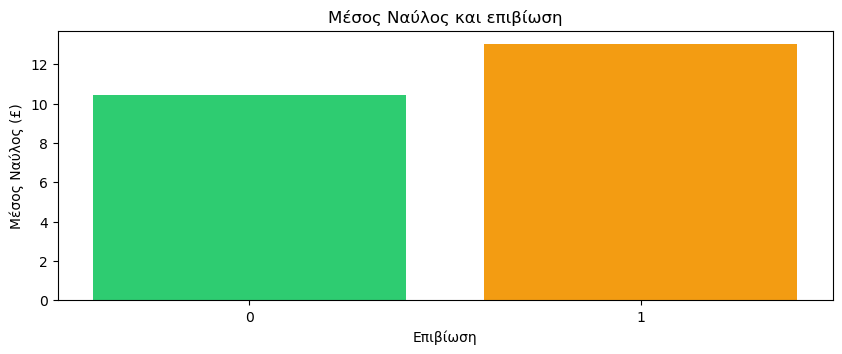

In [35]:
r_fare_surv = credit_risk_dataset_clean['loan_int_rate'].corr(credit_risk_dataset_clean['loan_status'])
print(f'Pearson r (Fare, Survived): {r_fare_surv:+.3f}')
print()

plt.figure(figsize=(10, 3.5))


grouped = credit_risk_dataset_clean.groupby('loan_status').agg(
    mean_loan_int_rate=('loan_int_rate', 'mean'),
).round(2)

plt.bar(grouped.index.astype(str), grouped['mean_loan_int_rate'], color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Μέσο Eπιτόκιο και Αθέτηση Δανείου')
plt.xlabel('loan_status')
plt.ylabel('loan_int_rate')
plt.show()

            mean_loan_int_rate  loan_status_rate
loan_grade                                      
A                         7.33              0.10
B                        11.00              0.16
C                        13.46              0.21
D                        15.36              0.59
E                        17.01              0.65
F                        18.61              0.70
G                        20.25              0.98


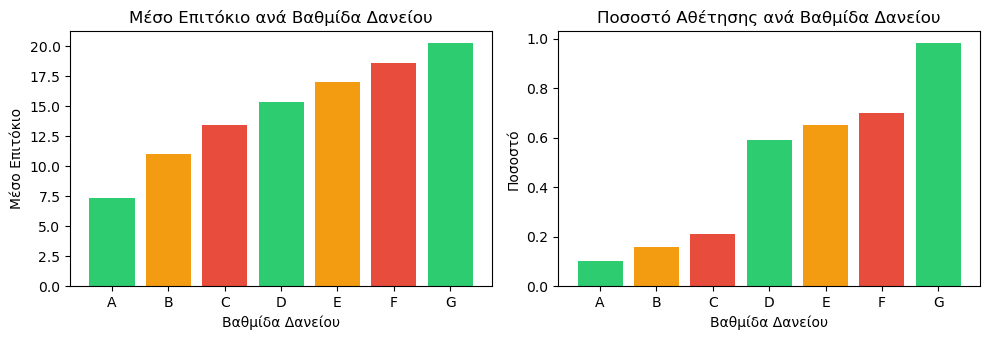

In [39]:
grouped = credit_risk_dataset_clean.groupby('loan_grade').agg(mean_loan_int_rate=('loan_int_rate', 'mean'),
    loan_status_rate=('loan_status', 'mean')).round(2)

print(grouped)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(grouped.index.astype(str), grouped['mean_loan_int_rate'], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Μέσο Επιτόκιο ανά Βαθμίδα Δανείου')
axes[0].set_xlabel('Βαθμίδα Δανείου')
axes[0].set_ylabel('Μέσο Επιτόκιο')

axes[1].bar(grouped.index.astype(str), grouped['loan_status_rate'], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Ποσοστό Aθέτησης ανά Βαθμίδα Δανείου')
axes[1].set_xlabel('Βαθμίδα Δανείου')
axes[1].set_ylabel('Ποσοστό')

plt.tight_layout()
plt.show()

In [40]:
print(credit_risk_dataset_clean.groupby('loan_grade')['loan_amnt'].mean().round(0))

loan_grade
A     8518.0
B     9976.0
C     9232.0
D    10833.0
E    12910.0
F    15207.0
G    18142.0
Name: loan_amnt, dtype: float64
